In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
import sys
import os
sys.path.append('../utils')
import database as db

# Create output directory if it doesn't exist
if not os.path.exists("fig/rq7"):
    os.makedirs("fig/rq7")

# Experiment 7: Severity × Vulnerability Type Cross-Tabulation

## Research Question
For each severity level, what percentage are memory vs. resource management vs. other vulnerability types?
Are memory vulnerabilities more/less severe than resource management vulnerabilities?

## Methodology
This analysis cross-tabulates vulnerability severity (Critical, High, Medium, Low, None) with SFP categories, focusing on:
- **Memory vulnerabilities**: Memory Access, Memory Management
- **Resource Management (RM)**: Resource Management
- **Other**: All other categories

## Hypothesis
If memory bugs are more severe, their decline is even more important for ecosystem security.

In [15]:
# Load vulnerability data with severity and SFP categories
df = pd.read_sql("""
    SELECT 
        c.id,
        c.package,
        c.severity,
        s.sfp_category
    FROM cve c
    JOIN cve_sfp s ON c.id = s.cve_id
""", con=db.conn)

print(f"Total vulnerability-SFP pairs: {len(df)}")
print(f"Unique vulnerabilities: {df['id'].nunique()}")
print(f"\nSeverity distribution:")
print(df.groupby('severity')['id'].nunique().sort_values(ascending=False))
print(f"\nSFP category distribution:")
print(df['sfp_category'].value_counts())

Total vulnerability-SFP pairs: 1790
Unique vulnerabilities: 1245

Severity distribution:
severity
Medium      458
High        445
Critical    151
Low         147
             42
None          2
Name: id, dtype: int64

SFP category distribution:
sfp_category
Resource Management     267
Memory Management       256
Memory Access           249
Tainted Input           187
Exception Management    122
Synchronization         107
Cryptography            107
Other                    99
Path Resolution          81
Risky Values             75
Information Leak         70
Authentication           57
Access Control           42
API                      34
Privilege                27
Predictability            9
Entry Points              1
Name: count, dtype: int64


## Define Vulnerability Type Groups

In [16]:
# Define vulnerability type groups
def classify_vul_type(sfp_category):
    """Classify SFP category into Memory, Resource Management, or Other."""
    memory_categories = ['Memory Access', 'Memory Management']
    rm_categories = ['Resource Management']
    
    if sfp_category in memory_categories:
        return 'Memory'
    elif sfp_category in rm_categories:
        return 'Resource Management'
    else:
        return 'Other'

# Apply classification
df['vul_type'] = df['sfp_category'].apply(classify_vul_type)

print("Vulnerability type distribution:")
print(df['vul_type'].value_counts())
print(f"\nPercentages:")
print(df['vul_type'].value_counts(normalize=True) * 100)

Vulnerability type distribution:
vul_type
Other                  1018
Memory                  505
Resource Management     267
Name: count, dtype: int64

Percentages:
vul_type
Other                  56.871508
Memory                 28.212291
Resource Management    14.916201
Name: proportion, dtype: float64


## Cross-Tabulation: Severity × Vulnerability Type

In [17]:
# Create cross-tabulation: count of each (severity, vul_type) combination
# Since one vulnerability can have multiple SFP categories, we need to handle this carefully

# Method 1: Count each (vulnerability, severity, vul_type) combination
cross_tab = pd.crosstab(df['severity'], df['vul_type'])
print("Cross-tabulation (raw counts):")
print(cross_tab)
print()

# Method 2: Row percentages (within each severity level)
cross_tab_pct = pd.crosstab(df['severity'], df['vul_type'], normalize='index') * 100
print("Cross-tabulation (row percentages):")
print(cross_tab_pct.round(2))

Cross-tabulation (raw counts):
vul_type  Memory  Other  Resource Management
severity                                    
              30     12                    4
Critical      96    120                   20
High         187    371                  131
Low           37    127                   19
Medium       153    385                   93
None           2      3                    0

Cross-tabulation (row percentages):
vul_type  Memory  Other  Resource Management
severity                                    
           65.22  26.09                 8.70
Critical   40.68  50.85                 8.47
High       27.14  53.85                19.01
Low        20.22  69.40                10.38
Medium     24.25  61.01                14.74
None       40.00  60.00                 0.00


## Detailed Analysis by Severity Level

In [18]:
# Analyze each severity level
severity_order = ['Critical', 'High', 'Medium', 'Low', 'None']
vul_types = ['Memory', 'Resource Management', 'Other']

print("=" * 70)
print("SEVERITY × VULNERABILITY TYPE ANALYSIS")
print("=" * 70)

for severity in severity_order:
    if severity not in cross_tab.index:
        continue
    
    print(f"\n{severity}:")
    total = cross_tab.loc[severity].sum()
    
    for vul_type in vul_types:
        if vul_type in cross_tab.columns:
            count = cross_tab.loc[severity, vul_type]
            pct = cross_tab_pct.loc[severity, vul_type]
            print(f"  {vul_type:20s}: {count:3d} ({pct:5.2f}%)")
    print(f"  {'Total':20s}: {total:3d}")

SEVERITY × VULNERABILITY TYPE ANALYSIS

Critical:
  Memory              :  96 (40.68%)
  Resource Management :  20 ( 8.47%)
  Other               : 120 (50.85%)
  Total               : 236

High:
  Memory              : 187 (27.14%)
  Resource Management : 131 (19.01%)
  Other               : 371 (53.85%)
  Total               : 689

Medium:
  Memory              : 153 (24.25%)
  Resource Management :  93 (14.74%)
  Other               : 385 (61.01%)
  Total               : 631

Low:
  Memory              :  37 (20.22%)
  Resource Management :  19 (10.38%)
  Other               : 127 (69.40%)
  Total               : 183

None:
  Memory              :   2 (40.00%)
  Resource Management :   0 ( 0.00%)
  Other               :   3 (60.00%)
  Total               :   5


## Statistical Test: Are Memory Vulns More Severe than Resource Management?

In [19]:
# Assign numeric severity scores for statistical testing
# Critical=4, High=3, Medium=2, Low=1, None=0
severity_map = {'Critical': 4, 'High': 3, 'Medium': 2, 'Low': 1, 'None': 0}
df['severity_score'] = df['severity'].map(severity_map)

# Get severity scores for Memory vs Resource Management vulnerabilities
memory_scores = df[df['vul_type'] == 'Memory']['severity_score'].dropna()
rm_scores = df[df['vul_type'] == 'Resource Management']['severity_score'].dropna()
other_scores = df[df['vul_type'] == 'Other']['severity_score'].dropna()

print("=" * 70)
print("STATISTICAL COMPARISON: MEMORY vs RESOURCE MANAGEMENT")
print("=" * 70)
print(f"\nMemory vulnerabilities:")
print(f"  Count: {len(memory_scores)}")
print(f"  Mean severity: {memory_scores.mean():.2f}")
print(f"  Median severity: {memory_scores.median():.2f}")
print(f"  Std dev: {memory_scores.std():.2f}")
print(f"  Severity distribution:")
print(memory_scores.value_counts().sort_index())

print(f"\nResource Management vulnerabilities:")
print(f"  Count: {len(rm_scores)}")
print(f"  Mean severity: {rm_scores.mean():.2f}")
print(f"  Median severity: {rm_scores.median():.2f}")
print(f"  Std dev: {rm_scores.std():.2f}")
print(f"  Severity distribution:")
print(rm_scores.value_counts().sort_index())

print(f"\nOther vulnerabilities:")
print(f"  Count: {len(other_scores)}")
print(f"  Mean severity: {other_scores.mean():.2f}")
print(f"  Median severity: {other_scores.median():.2f}")
print(f"  Std dev: {other_scores.std():.2f}")

STATISTICAL COMPARISON: MEMORY vs RESOURCE MANAGEMENT

Memory vulnerabilities:
  Count: 475
  Mean severity: 2.71
  Median severity: 3.00
  Std dev: 0.89
  Severity distribution:
severity_score
0.0      2
1.0     37
2.0    153
3.0    187
4.0     96
Name: count, dtype: int64

Resource Management vulnerabilities:
  Count: 263
  Mean severity: 2.58
  Median severity: 3.00
  Std dev: 0.74
  Severity distribution:
severity_score
1.0     19
2.0     93
3.0    131
4.0     20
Name: count, dtype: int64

Other vulnerabilities:
  Count: 1006
  Mean severity: 2.48
  Median severity: 2.00
  Std dev: 0.87


In [20]:
# Mann-Whitney U test (non-parametric) to compare Memory vs RM severity
from scipy.stats import mannwhitneyu, kruskal

# Mann-Whitney U test
stat, p_value = mannwhitneyu(memory_scores, rm_scores, alternative='two-sided')
print("=" * 70)
print("MANN-WHITNEY U TEST: Memory vs Resource Management")
 
print("=" * 70)
print(f"U-statistic: {stat:.2f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Significant difference (p < 0.05)")
else:
    print("Result: No significant difference (p >= 0.05)")

# Kruskal-Wallis test across all three groups
h_stat, p_value_kw = kruskal(memory_scores, rm_scores, other_scores)
print("\n" + "=" * 70)
print("KRUSKAL-WALLIS TEST: Memory vs RM vs Other")
print("=" * 70)
print(f"H-statistic: {h_stat:.2f}")
print(f"P-value: {p_value_kw:.4f}")
if p_value_kw < 0.05:
    print("Result: Significant difference across groups (p < 0.05)")
else:
    print("Result: No significant difference across groups (p >= 0.05)")

MANN-WHITNEY U TEST: Memory vs Resource Management
U-statistic: 67853.50
P-value: 0.0381
Result: Significant difference (p < 0.05)

KRUSKAL-WALLIS TEST: Memory vs RM vs Other
H-statistic: 24.02
P-value: 0.0000
Result: Significant difference across groups (p < 0.05)


## Visualization 1: Stacked Bar Chart of Severity by Vulnerability Type

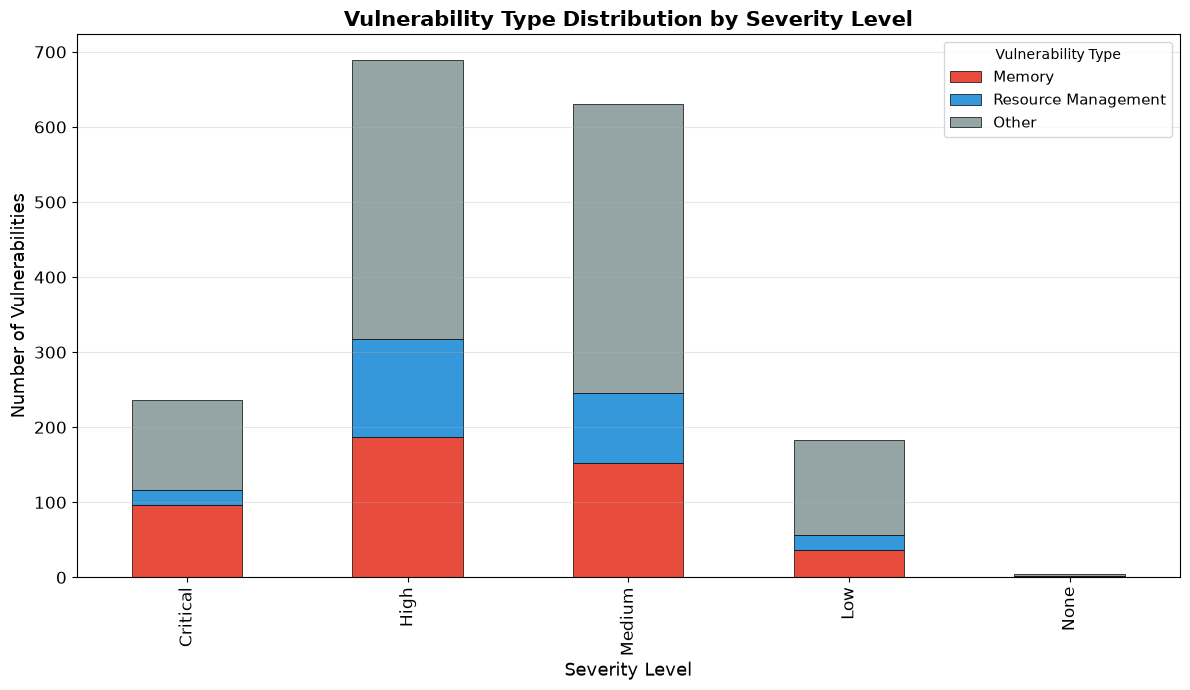

Saved: fig/rq7/severity_by_vul_type_stacked.png


In [21]:
# Create stacked bar chart showing vulnerability type distribution within each severity
fig, ax = plt.subplots(figsize=(12, 7))

# Reorder columns and rows
cross_tab_ordered = cross_tab.reindex(severity_order)[vul_types]
cross_tab_pct_ordered = cross_tab_pct.reindex(severity_order)[vul_types]

# Plot stacked bar chart
colors = ['#e74c3c', '#3498db', '#95a5a6']  # Red for Memory, Blue for RM, Gray for Other
cross_tab_ordered.plot(kind='bar', stacked=True, ax=ax, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Severity Level', fontsize=13)
ax.set_ylabel('Number of Vulnerabilities', fontsize=13)
ax.set_title('Vulnerability Type Distribution by Severity Level', fontsize=15, fontweight='bold')
ax.legend(title='Vulnerability Type', loc='upper right', fontsize=11)
ax.tick_params(axis='both', labelsize=12)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('fig/rq7/severity_by_vul_type_stacked.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig/rq7/severity_by_vul_type_stacked.png")

## Visualization 2: Grouped Bar Chart (Percentages)

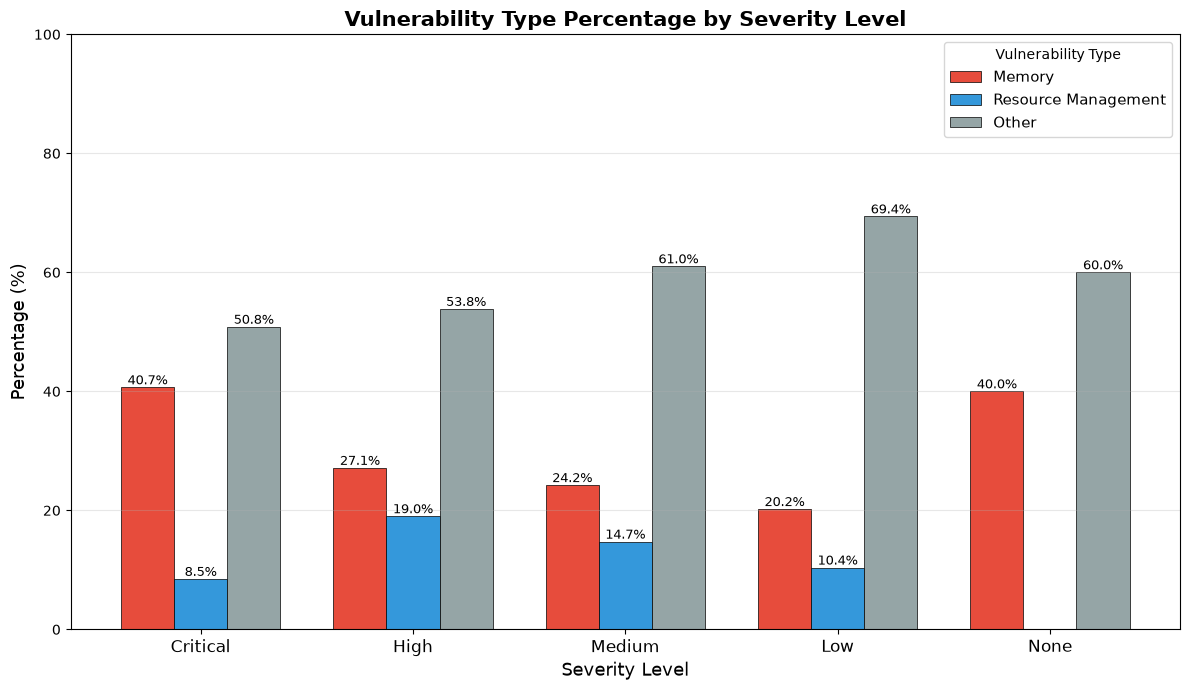

Saved: fig/rq7/severity_by_vul_type_pct.png


In [22]:
# Create grouped bar chart showing percentages
fig, ax = plt.subplots(figsize=(12, 7))

x = np.arange(len(severity_order))
width = 0.25

memory_pct = [cross_tab_pct_ordered.loc[s, 'Memory'] if s in cross_tab_pct_ordered.index else 0 for s in severity_order]
rm_pct = [cross_tab_pct_ordered.loc[s, 'Resource Management'] if s in cross_tab_pct_ordered.index else 0 for s in severity_order]
other_pct = [cross_tab_pct_ordered.loc[s, 'Other'] if s in cross_tab_pct_ordered.index else 0 for s in severity_order]

bars1 = ax.bar(x - width, memory_pct, width, label='Memory', color='#e74c3c', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, rm_pct, width, label='Resource Management', color='#3498db', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, other_pct, width, label='Other', color='#95a5a6', edgecolor='black', linewidth=0.5)

ax.set_xlabel('Severity Level', fontsize=13)
ax.set_ylabel('Percentage (%)', fontsize=13)
ax.set_title('Vulnerability Type Percentage by Severity Level', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(severity_order, fontsize=12)
ax.legend(title='Vulnerability Type', loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 100)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 5:  # Only label if bar is tall enough
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.1f}%',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('fig/rq7/severity_by_vul_type_pct.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig/rq7/severity_by_vul_type_pct.png")

## Visualization 3: Heatmap of Severity × Vulnerability Type

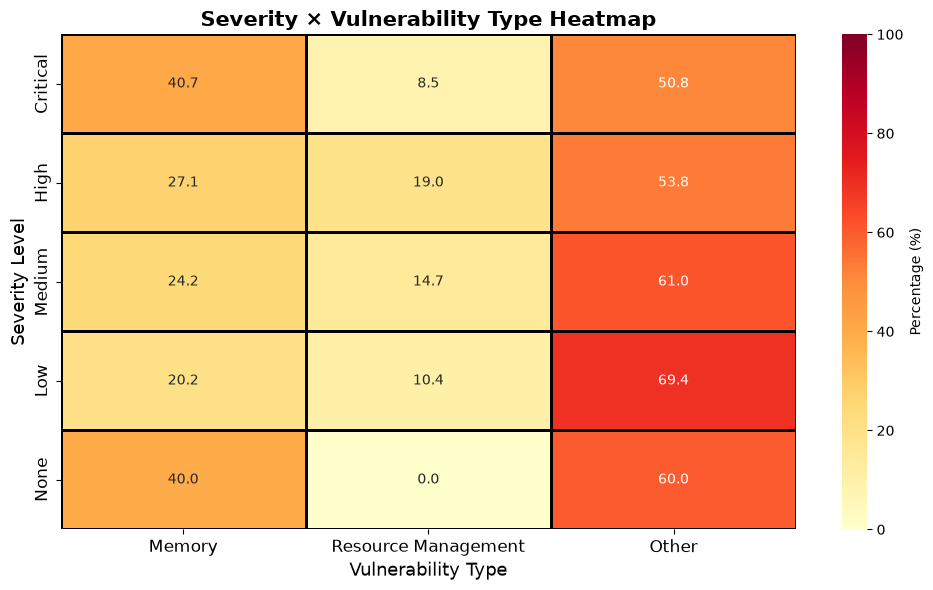

Saved: fig/rq7/severity_vul_type_heatmap.png


In [23]:
# Create heatmap
fig, ax = plt.subplots(figsize=(10, 6))

# Plot heatmap with percentages
sns.heatmap(cross_tab_pct_ordered, 
            annot=True, 
            fmt='.1f', 
            cmap='YlOrRd',
            cbar_kws={'label': 'Percentage (%)'},
            linewidths=1,
            linecolor='black',
            vmin=0, 
            vmax=100)

ax.set_xlabel('Vulnerability Type', fontsize=13)
ax.set_ylabel('Severity Level', fontsize=13)
ax.set_title('Severity × Vulnerability Type Heatmap', fontsize=15, fontweight='bold')
ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig('fig/rq7/severity_vul_type_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig/rq7/severity_vul_type_heatmap.png")

## Summary and Key Findings

In [24]:
print("=" * 70)
print("SUMMARY OF FINDINGS")
print("=" * 70)

# Calculate overall percentages
total_memory = cross_tab['Memory'].sum()
total_rm = cross_tab['Resource Management'].sum()
total_other = cross_tab['Other'].sum()
total_all = total_memory + total_rm + total_other

print(f"\nOverall vulnerability type distribution:")
print(f"  Memory: {total_memory} ({total_memory/total_all*100:.1f}%)")
print(f"  Resource Management: {total_rm} ({total_rm/total_all*100:.1f}%)")
print(f"  Other: {total_other} ({total_other/total_all*100:.1f}%)")

# Calculate severity distribution
print(f"\nSeverity distribution:")
for severity in severity_order:
    if severity in cross_tab.index:
        count = cross_tab.loc[severity].sum()
        pct = count / total_all * 100
        print(f"  {severity}: {count} ({pct:.1f}%)")

# Key insights
print(f"\n" + "=" * 70)
print("KEY INSIGHTS")
print("=" * 70)

# Find which severity has highest memory percentage
if 'Memory' in cross_tab_pct_ordered.columns:
    max_memory_severity = cross_tab_pct_ordered['Memory'].idxmax()
    max_memory_pct = cross_tab_pct_ordered['Memory'].max()
    print(f"\n1. Memory vulnerabilities are most prevalent in: {max_memory_severity} ({max_memory_pct:.1f}%)")

# Find which severity has highest RM percentage
if 'Resource Management' in cross_tab_pct_ordered.columns:
    max_rm_severity = cross_tab_pct_ordered['Resource Management'].idxmax()
    max_rm_pct = cross_tab_pct_ordered['Resource Management'].max()
    print(f"2. Resource Management vulnerabilities are most prevalent in: {max_rm_severity} ({max_rm_pct:.1f}%)")

# Compare mean severity
print(f"\n3. Mean severity comparison:")
print(f"   Memory: {memory_scores.mean():.2f}")
print(f"   Resource Management: {rm_scores.mean():.2f}")
print(f"   Other: {other_scores.mean():.2f}")

if memory_scores.mean() > rm_scores.mean():
    print(f"   → Memory vulnerabilities are MORE severe on average")
elif memory_scores.mean() < rm_scores.mean():
    print(f"   → Resource Management vulnerabilities are MORE severe on average")
else:
    print(f"   → Memory and Resource Management vulnerabilities have SIMILAR severity")

print(f"\n4. Research implication:")
if memory_scores.mean() > rm_scores.mean():
    print(f"   Memory vulnerabilities are more severe, so their decline is particularly important")
    print(f"   for improving Rust ecosystem security.")
else:
    print(f"   The severity distribution suggests different priorities for security focus.")

SUMMARY OF FINDINGS

Overall vulnerability type distribution:
  Memory: 505 (28.2%)
  Resource Management: 267 (14.9%)
  Other: 1018 (56.9%)

Severity distribution:
  Critical: 236 (13.2%)
  High: 689 (38.5%)
  Medium: 631 (35.3%)
  Low: 183 (10.2%)
  None: 5 (0.3%)

KEY INSIGHTS

1. Memory vulnerabilities are most prevalent in: Critical (40.7%)
2. Resource Management vulnerabilities are most prevalent in: High (19.0%)

3. Mean severity comparison:
   Memory: 2.71
   Resource Management: 2.58
   Other: 2.48
   → Memory vulnerabilities are MORE severe on average

4. Research implication:
   Memory vulnerabilities are more severe, so their decline is particularly important
   for improving Rust ecosystem security.
